In [1]:
import pathlib
import seaborn
import umap
import torch

import numpy as np
import m2aia as m2
import matplotlib.pyplot as plt 

from torch.utils.data import DataLoader, SubsetRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import Adam

from sklearn import cluster
from scipy import signal
from torchvision import transforms
from pathlib import Path
from SimCLR.code.models import CLR, ContrastiveLoss


/opt/anaconda3/envs/stimage2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset

import m2aia as m2

# adaptions to gaussian noise to work on single channeled images
def gaussian_noise(pix, mean=0, sigmas=(0.001, 0.2)):
    sigma = np.random.uniform(sigmas[0], sigmas[1])   # randomize magnitude
    pix = pix * 255
    # adaptively tune the magnitude, hardcode according to the data distribution. every img is [0, 255]
    if pix[pix > 25].shape[0] > 0:       # 1st thre 25
        aver = torch.mean(pix[pix > 25])
    elif pix[pix > 20].shape[0] > 0:     # 2nd thre 20
        aver = torch.mean(pix[pix > 20])
    elif pix[pix > 15].shape[0] > 0:     # 3nd thre 15
        aver = torch.mean(pix[pix > 15])
    elif pix[pix > 10].shape[0] > 0:     # 4nd thre 10
        aver = torch.mean(pix[pix > 10])
    else:
        aver = torch.mean(pix)
        
    sigma_adp = sigma/153*aver           # 153, 0 homogeneous img average pixel intensity

    # scale gray img to [0, 1]
    pix = pix / 255
    # generate gaussian noise
    noise = np.random.normal(mean, sigma_adp, pix.shape)
    # generate image with gaussian noise
    pix_out = pix + torch.tensor(noise)
    pix_out = np.clip(pix_out, 0, 1)
    img_out = pix_out # convert to PIL image
    return torch.as_tensor(img_out, dtype=torch.float32)


class AugmentedDataset(Dataset):
    ''' Torch Dataset using a pyM2aia Dataset to generate data.
        Parameters:
            dataset: m2.BaseDataSet
            transform: transformation function returning an augmented element of 'dataset'
    '''
    def __init__(self, dataset: m2.BaseDataSet, transform):
        super().__init__()
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return self.dataset.__len__()

    def __getitem__(self, index):
        I = self.dataset[index]
        X = self.transform(I)
        Y = self.transform(I)
        return X, Y

In [3]:
# Clustering Parameters
n_clusters = 5
n_neighbors = 10

# Network Parameters
# model input dimension for height and width of the input images
# ion images are center cropped to the max dimension of the image and subsequently resized to a size of 124x124
# see augmentation functions
target_input_size = 124 
epochs = 10
batch_size = 512

In [4]:
import subprocess
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)

In [31]:
Sample_ls = [
            # "Ctrl_1", 
            #  "Ctrl_1", 
            "Treated_1", 
            # "Treated_2"
             ]
Sample_ls_ = [
            # "control 1", 
            #   "control 2", 
            "treated 1", 
            # "treated 2"
              ]

In [32]:
#===================================
# 1.1 Load image handles
#===================================
image_handles = []
for f in Sample_ls_:
    f_ = str(MALDI_RAW_PATH / f"dhb-tissue region {f}.imzML")
    I = m2.ImzMLReader(f_,
                       pooling=m2.m2PoolingMaximum,
                       normalization=m2.m2NormalizationTIC)
    image_handles.append(I)
    print(I.GetShape())
max_dim = np.max(I.GetShape())

[275.533] [imzML]: /home/uqxtan9/Q1851/Xiao/Working_project/MB/Xenium_Brain/MALDI_RAW/imzml_file/dhb-tissue region treated 1.imzML
	[pixel size (mm)]: 0.020000x0.020000x0.010000
	[image dimension]: 325x507x1
	[num spectra]: 116598
	[spec. type]: ProcessedCentroid
	[mass range]: 160.809851 to 2999.028857 with #1500 measurements
	[normalization]: TIC
[325 507   1]


In [33]:
#===================================
# 1.1 Pick peaks (mean spectrum)
#===================================
mean = I.GetMeanSpectrum()
min_indices = signal.argrelmin(mean,order=50)[0]
xs = I.GetXAxis()
peaks = signal.find_peaks(mean, height=np.median(mean)*0.1)
centroids = xs[peaks[0]].tolist()
print("Number of centroids", len(centroids))

Number of centroids 415


In [34]:
np.median(mean)

0.00029091228864189884

In [35]:
# centroids

In [36]:
#===================================
# Initialize the ion image Dataset
#===================================
# Transformations functions using torchvision's transforms
# are used to create a uniform output of the ion image generator (dataset)

# 1. - 99th Quantile normalization 
#    - clipping values between 0 and 1 
#    - conversion to a torch tensor
# 2. Center cropping
# 3. Resizing

transform_rm_outlies_center_crop_resize = transforms.Compose([
                                          transforms.Lambda(lambda x : torch.Tensor(np.clip(x / np.quantile(x,0.999),0,1))),
                                          transforms.CenterCrop(max_dim),
                                          transforms.Resize(target_input_size)])

dataset = m2.IonImageDataset(image_handles, 
                            centroids=centroids, 
                            tolerance=75, 
                            tolerance_type='ppm', 
                            buffer_type='memory', 
                            transforms=transform_rm_outlies_center_crop_resize)

# print(dataset[0].shape)
# the output shape is now a tensor of shape [1,124,124]

In [37]:
#===================================
# 1.3 Initialize the augmented ion image 
# Dataset which is used during training
#===================================
# Using: from Example_V_Helpers import gaussian_noise, AugmentedDataset

# Dataset returns two augmentations of the same ion image which follow the original publications
# Hu,H. et al. (2022) Self-supervised clustering of mass spectrometry imaging data using contrastive learning. Chem. Sci., 13, 90–98.
# 1. Conversion to a tensor of type float32
# 2. Apply gaussian blur
# 3. Color jitter (in this case only grayscale jitter, but to be conform wit the original work we use the same term here)
# 4. Add gaussian noise

blur_kernel_size = 9
augmentations = transforms.Compose([transforms.GaussianBlur(blur_kernel_size, sigma=(0.01, 0.75)), 
                                    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2), 
                                    transforms.Lambda(gaussian_noise)])

# the Augmentation dataset now queries a sample from the dataset
# and returns two augmented versions of the ion-image
aug_dataset = AugmentedDataset(dataset, augmentations)

# print(aug_dataset[0][0].shape, aug_dataset[0][1].shape)
# the output shape is still two tensors of shape [1,124,124]

In [38]:
#===================================
# 2 Initializing the SimCLR model
#===================================
m = CLR()
m = m.cuda()

# for reproducibility load/save the model
models_root = pathlib.Path("models")
models_root.mkdir(exist_ok=True)
model_path = models_root.joinpath("Example_V_0.model")

if model_path.exists():
    state_dict = torch.load(str(model_path))
    m.load_state_dict(state_dict)
else:
    torch.save(m.state_dict(), str(model_path))
    

Loaded pretrained weights for efficientnet-b0


In [39]:
#===================================
# 2.1 Predict embeddings of the images
# using the unmodified efficient net model
#===================================

m.eval()
A = None
for ionImage in dataset:
    # Dataset returns item of form [C,H,W]
    # Network requires items of form [N,C,H,W]
    _, embedding = m(torch.tensor(ionImage[None,...]).cuda())
    embedding = embedding.cpu().detach().numpy()
    if A is None:
        A = embedding
    else:
        A = np.concatenate([A, embedding])

/tmp/ipykernel_428732/3646328705.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  _, embedding = m(torch.tensor(ionImage[None,...]).cuda())


/opt/anaconda3/envs/stimage2/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


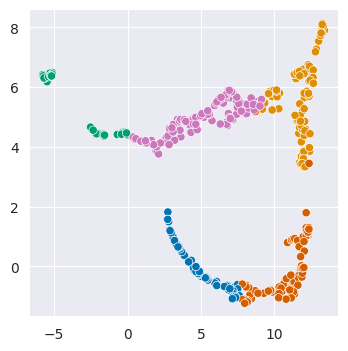

In [40]:
#===================================
# 2.2 Cluster the results using SpectralCustering
#===================================
predictor =  cluster.SpectralClustering(random_state=42,
                                   n_clusters=n_clusters, 
                                   n_neighbors = n_neighbors,
                                   affinity = 'nearest_neighbors', 
                                   assign_labels='discretize')
clusteredA = predictor.fit_predict(A)

#===================================
# 2.3 Use UMAP embeddings
#===================================
transformer = umap.UMAP(random_state=65)
transformedA = transformer.fit_transform(A)

seaborn.set_style('darkgrid')
plt.figure(figsize=(4,4))
fig = seaborn.scatterplot(x=transformedA[:,0], y=transformedA[:,1],hue=clusteredA, legend=False, palette="colorblind")


# plt.savefig(f"{target_path}/FigS81_pre.eps", dpi=350)
# plt.savefig(f"{target_path}/FigS81_pre.tif", dpi=350)
# plt.savefig(f"{target_path}/FigS81_pre.png", dpi=350)

In [41]:
#===================================
# 3 Load trained model parameters
#===================================
models_root = pathlib.Path("models")
models_root.mkdir(exist_ok=True)
model_path = models_root.joinpath("Example_V_1.model")

if model_path.exists():
    state_dict = torch.load(str(model_path))
    m.load_state_dict(state_dict)
else:
#===================================
# 3 Start finetuning and save model
#===================================

    loss = ContrastiveLoss(batch_size)
    loss = loss.cuda()

    optim = Adam(m.parameters())
    scheduler = CosineAnnealingLR(optim, epochs)

    # the batch generator if pytorch is used in combination with the augmented dataset
    # to produce batches for the training procedure
    dataloader = DataLoader(aug_dataset,
                            batch_size = batch_size, 
                            sampler = SubsetRandomSampler(list(range(len(aug_dataset)))),
                            pin_memory = True,
                            drop_last = True)

    m.train()
    ## main fit steps
    total_losses = []
    for epoch in range(epochs):
        epoch_losses = []
        for i, [X, Y] in enumerate(dataloader):
            X = X.cuda(non_blocking=True)
            Y = Y.cuda(non_blocking=True)
            _, proj_X = m(X)
            _, proj_Y = m(Y)
            loss_value = loss(proj_X, proj_Y)
            epoch_losses.append(loss_value)
            
            # backward
            optim.zero_grad()
            loss_value.backward()
            optim.step()

        # update lr
        scheduler.step()
        losses_np = torch.tensor(epoch_losses).cpu().numpy()
        print('epoch {} loss: {}'.format(epoch, np.mean(losses_np)) , end='\r')
    
    torch.save(m.state_dict(), str(model_path))

In [42]:
#===================================
# 3.1 Predict embeddings of the images
# using the now finetuned model
#===================================

m.eval()
hatA = None
for ionImage in dataset:
    # Dataset returns item of form [C,H,W]
    # Network requires items of form [N,C,H,W]
    _, embedding = m(torch.tensor(ionImage[None,...]).cuda())
    embedding = embedding.cpu().detach().numpy()
    if hatA is None:
        hatA = embedding
    else:
        hatA = np.concatenate([hatA, embedding])

/tmp/ipykernel_428732/344714076.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  _, embedding = m(torch.tensor(ionImage[None,...]).cuda())


/opt/anaconda3/envs/stimage2/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


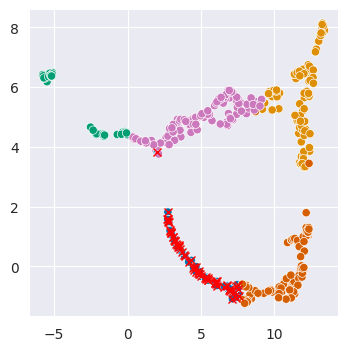

In [46]:
#===================================
# 3.2 Cluster the results using SpectralCustering
#===================================
predictor = cluster.SpectralClustering(random_state=42,
                                n_clusters=n_clusters, 
                                n_neighbors = n_neighbors,
                                affinity = 'nearest_neighbors', 
                                assign_labels='discretize')
clusteredHatA = predictor.fit_predict(hatA)

#===================================
# 3.3 Use UMAP embeddings
#===================================
transformer = umap.UMAP(random_state=65)
transformedHatA = transformer.fit_transform(hatA)

# highlighted cluster
targetCluster = 0

seaborn.set_style('darkgrid')
plt.figure(figsize=(4,4))
import pandas as pd
# data = pd.DataFrame(np.concatenate([r, c[...,None]],axis=1))

fig = seaborn.scatterplot(x=transformedHatA[:,0], y=transformedHatA[:,1], hue=clusteredHatA ,legend=False, palette='colorblind')
plt.plot(transformedHatA[:,0][clusteredHatA == targetCluster], transformedHatA[:,1][clusteredHatA == targetCluster], 'rx')


# plt.title("B", {'fontweight' : 'bold', 'verticalalignment': 'baseline', 'horizontalalignment': 'left'})
# plt.savefig(f"{target_path}/FigS83_post.eps", dpi=350)
# plt.savefig(f"{target_path}/FigS83_post.tif", dpi=350)
# plt.savefig(f"{target_path}/FigS83_post.png", dpi=350)

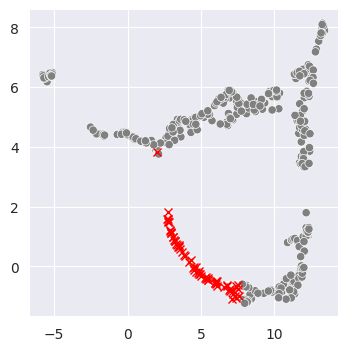

In [47]:
#===================================
# 2.3 Use UMAP embeddings
#===================================
# r_0 = t.transform(dt_0)
# c_0 = km_0.fit_predict(r_0)

seaborn.set_style('darkgrid')
plt.figure(figsize=(4,4))
d = seaborn.color_palette("light:grey", as_cmap=True)
markedClusters = clusteredHatA
markedClusters[markedClusters!=targetCluster] = 250
fig = seaborn.scatterplot(x=transformedA[:,0], y=transformedA[:,1], hue=markedClusters, legend=False, palette=d)
plt.plot(transformedA[:,0][clusteredHatA == targetCluster], transformedA[:,1][clusteredHatA == targetCluster], 'rx')
# plt.plot(r_0[:,0][c == 2], r_0[:,1][c == 2], 'or')
# plt.title("A", {'fontweight' : 'bold',
#  'verticalalignment': 'baseline',
#  'horizontalalignment': 'left'})
# plt.savefig(f"{target_path}/FigS81_pre.eps", dpi=350)
# plt.savefig(f"{target_path}/FigS81_pre.tif", dpi=350)
# plt.savefig(f"{target_path}/FigS81_pre.png", dpi=350)

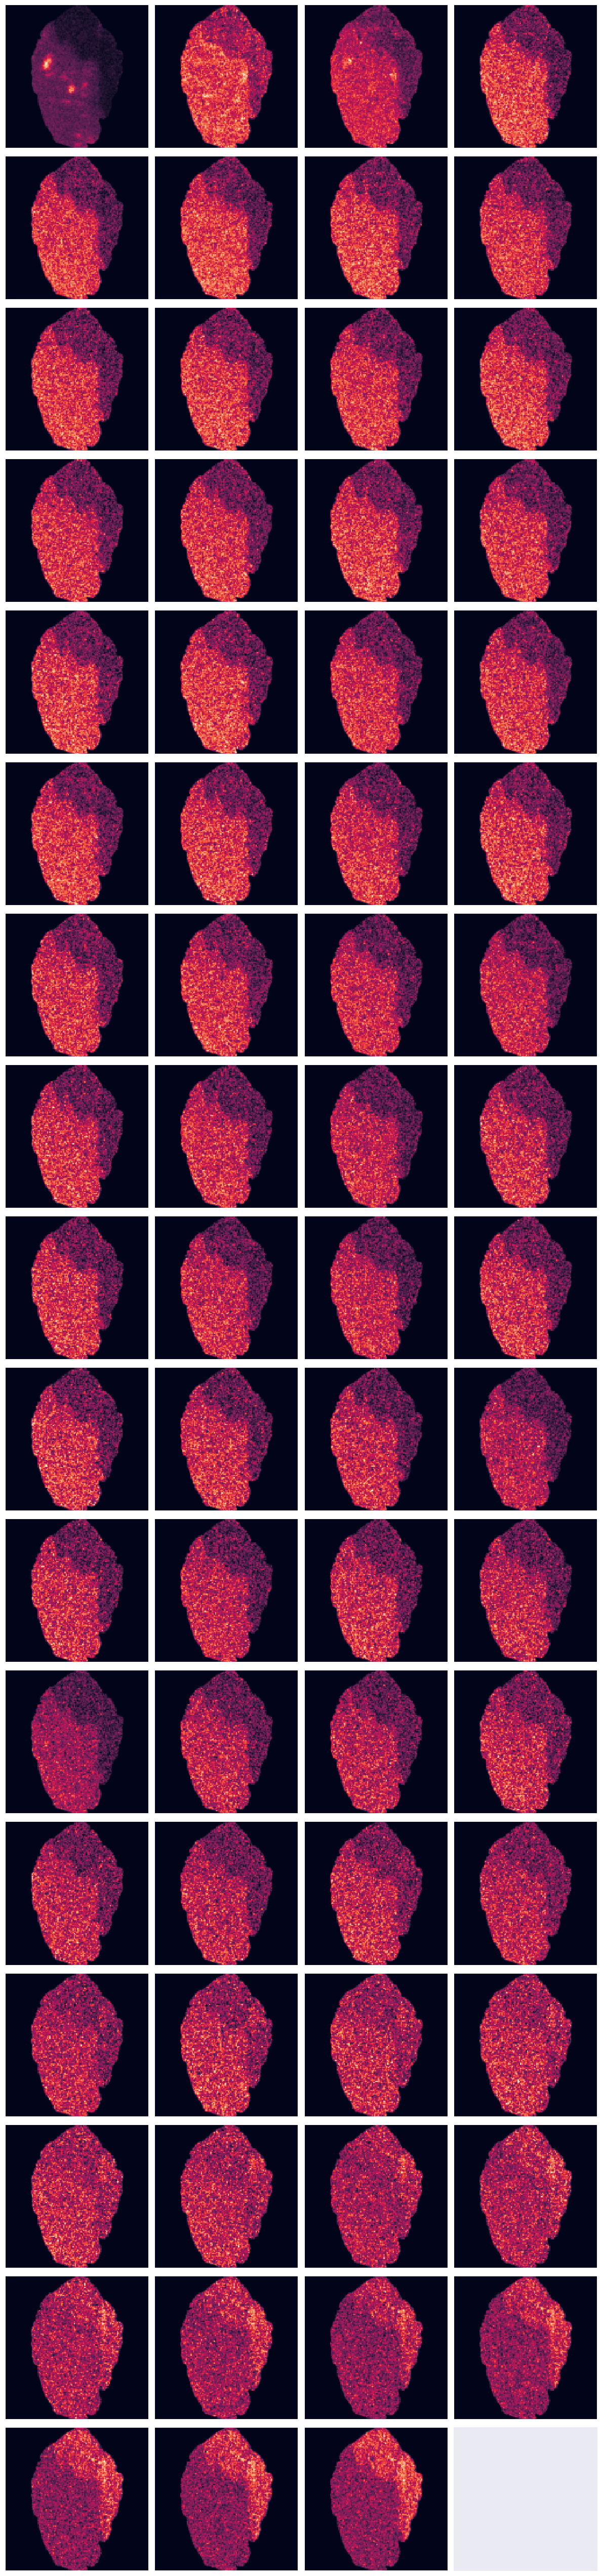

In [48]:
import seaborn_image as isns

ids = np.argwhere(clusteredHatA == targetCluster).flatten().tolist()
images=[]
for id in ids:
    images.append(dataset[id][0])

isns.ImageGrid(images, cbar=False, col_wrap=4)
# plt.savefig(f"{target_path}/FigS8Cluster.png", dpi=350)